In [ ]:
import pandas as pd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/News/data.csv')
df.head(5)

,URLs,Headline,Body,Label
0,http://www.bbc.com/news/world-us-canada-414191...,Four ways Bob Corker skewered Donald Trump,Image copyright Getty Images\nOn Sunday mornin...,1
1,https://www.reuters.com/article/us-filmfestiva...,Linklater's war veteran comedy speaks to moder...,"LONDON (Reuters) - “Last Flag Flying”, a comed...",1
2,https://www.nytimes.com/2017/10/09/us/politics...,Trump’s Fight With Corker Jeopardizes His Legi...,The feud broke into public view last week when...,1
3,https://www.reuters.com/article/us-mexico-oil-...,Egypt's Cheiron wins tie-up with Pemex for Mex...,MEXICO CITY (Reuters) - Egypt’s Cheiron Holdin...,1
4,http://www.cnn.com/videos/cnnmoney/2017/10/08/...,Jason Aldean opens 'SNL' with Vegas tribute,"Country singer Jason Aldean, who was performin...",1


In [ ]:
df['text'] = df['Headline'].fillna('') + " " + df['Body']
df = df[['text', 'Label']]
df.head()

,text,Label
0,Four ways Bob Corker skewered Donald Trump Ima...,1
1,Linklater's war veteran comedy speaks to moder...,1
2,Trump’s Fight With Corker Jeopardizes His Legi...,1
3,Egypt's Cheiron wins tie-up with Pemex for Mex...,1
4,Jason Aldean opens 'SNL' with Vegas tribute Co...,1


In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
pip install nltk

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
df['text'] = df['text'].astype(str)

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
  text = text.split()
  text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
  return " ".join(text)

df['clean_text'] = df['text'].apply(clean_text)
df.head()



,text,Label,clean_text
0,Four ways Bob Corker skewered Donald Trump Ima...,1,four way bob corker skewered donald trump imag...
1,Linklater's war veteran comedy speaks to moder...,1,linklaters war veteran comedy speaks modern am...
2,Trump’s Fight With Corker Jeopardizes His Legi...,1,trump fight corker jeopardizes legislative age...
3,Egypt's Cheiron wins tie-up with Pemex for Mex...,1,egypt cheiron win tieup pemex mexican onshore ...
4,Jason Aldean opens 'SNL' with Vegas tribute Co...,1,jason aldean open snl vega tribute country sin...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
y = df['Label']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 2000)
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(x_train, y_train)
nb_pred = nb.predict(x_test)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Logistic Regression:\n", classification_report(y_test, lr_pred))
print("Naive Bayes:\n", classification_report(y_test, nb_pred))


Logistic Regression:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       455
           1       0.96      0.97      0.97       347

    accuracy                           0.97       802
   macro avg       0.97      0.97      0.97       802
weighted avg       0.97      0.97      0.97       802

Naive Bayes:
               precision    recall  f1-score   support

           0       0.97      0.87      0.92       455
           1       0.85      0.96      0.91       347

    accuracy                           0.91       802
   macro avg       0.91      0.92      0.91       802
weighted avg       0.92      0.91      0.91       802



In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(x_train, y_train)
svm_pred = svm.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("SV Classification Report:\n", classification_report(y_test, svm_pred))
print("Accuracy:", accuracy_score(y_test, svm_pred))

SV Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       455
           1       0.99      0.98      0.98       347

    accuracy                           0.98       802
   macro avg       0.98      0.98      0.98       802
weighted avg       0.98      0.98      0.98       802

Accuracy: 0.983790523690773


In [ ]:
comparison_data = {
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    "Precision (Fake News)" : [
        classification_report(y_test, lr_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, nb_pred, output_dict=True)['1']['precision'],
        classification_report(y_test, svm_pred, output_dict=True)['1']['precision']
    ],
    "Recall (Fake News)": [
        classification_report(y_test, lr_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, nb_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, svm_pred, output_dict=True)['1']['recall']
    ],
    "F1-Score (Fake News)": [
        classification_report(y_test, lr_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, nb_pred, output_dict=True)['1']['f1-score'],
        classification_report(y_test, svm_pred, output_dict=True)['1']['f1-score']
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Final Model": ["NO", "NO", "✔ YES"]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Precision (Fake News),Recall (Fake News),F1-Score (Fake News),Accuracy,Final Model
0,Logistic Regression,0.962963,0.974063,0.968481,0.972569,NO
1,Naive Bayes,0.854220,0.962536,0.905149,0.912718,NO
2,SVM,0.985465,0.976945,0.981187,0.983791,✔ YES


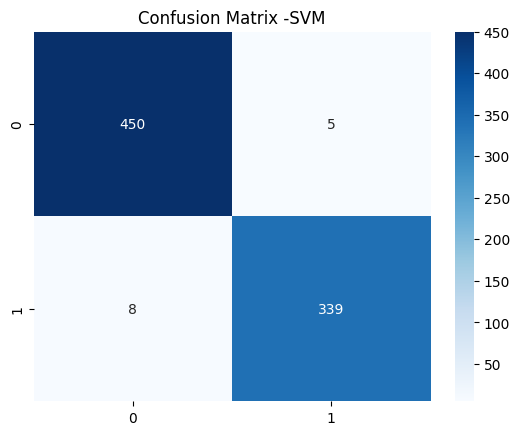

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix -SVM")
plt.show()
